# Text Mining

Analiza tematów i porównanie sentymentów w 4 subredditach muzycznych.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from nltk.corpus import stopwords

import spacy
from gensim import corpora
from gensim.models import LdaModel
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download('punkt_tab', quiet=True)

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
sns.set_theme(style="whitegrid")
Path("../outputs/figures").mkdir(parents=True, exist_ok=True)

df = pd.read_csv("../data/processed/all_subreddits_sample.csv")
print(df.shape)
df.head()

KeyboardInterrupt: 

## 1. Preprocessing

In [ ]:
stop_words = set(stopwords.words("english"))

# dodatkowe słowa które nie wnoszą nic do analizy muzycznej
extra_stopwords = {
    "like", "just", "get", "got", "one", "know", "think", "really",
    "would", "also", "even", "much", "still", "way", "good", "make",
    "people", "time", "music", "song", "songs", "album", "artist",
    "https", "http", "www", "com", "reddit", "amp"
}
stop_words.update(extra_stopwords)


from tqdm import tqdm

def preprocess_batch(texts):
    result = []
    for doc in tqdm(nlp.pipe(texts, batch_size=500), total=len(texts), desc="Lemmatyzacja"):
        tokens = [
            token.lemma_
            for token in doc
            if token.is_alpha
            and token.lemma_ not in stop_words
            and len(token.lemma_) > 2
        ]
        result.append(tokens)
    return result

df["tokens"] = preprocess_batch(df["body"].fillna(""))

print("Przykład tokenów:")
print(df["tokens"].iloc[0])

Lemmatyzacja: 100%|██████████| 2544183/2544183 [2:15:58<00:00, 311.85it/s]  


Przykład tokenów:
['read', 'Baby', 'Keem', 'tweet', 'complain', 'right', 'Coachella', 'announcement', 'Coronavirus', 'delay', 'Kendrick', 'rollout']


In [24]:
suspicious_pop = df[
    (df["subreddit"] == "popheads") & 
    (df["body"].str.contains("popheads however|query|remove follow", case=False, na=False))
]
print(suspicious_pop["author"].value_counts().head(10))
if len(suspicious_pop) > 0:
    print(suspicious_pop["body"].iloc[0])
else:
    print("Brak wyników — szukam inaczej")
    sample = df[df["subreddit"] == "popheads"].sample(5, random_state=42)
    print(sample["body"].tolist())
    
suspicious_indie = df[
    (df["subreddit"] == "indieheads") & 
    (df["body"].str.contains("post.*remov|remov.*post", case=False, na=False))
]
print(suspicious_indie["author"].value_counts().head(10))
print(suspicious_indie["body"].iloc[0])

author
ignitethephoenix    18
Jelvayra             5
CalmTheHead          3
NaiveChampion        2
yunglethe            2
MinimumCare          1
yaboyanu             1
luigimelekrause      1
Me-Luigi             1
BrewingAyahuasca     1
Name: count, dtype: int64
It's so buggy. A lot of times a tweet with 7,000 likes doesn't show up when you filter for 5,000 but does when you filter for 500. Or, at the moment searching any query with "min_faves:3500" or more returns no results on my end when there are plenty above that amount. Worse, some tweets don't show up in Twitter search, period. For example, [this tweet](https://twitter.com/real_fan08/status/1213962972604665856) doesn't come up when searching for [those exact keywords on Twitter](https://twitter.com/search?q=have%20the%20same%20energy%20when%20taylor%20cries%20toxic%20male%20masculinity&amp;src=typed_query&amp;f=live) so you have to use [Google](https://www.google.com/search?q=have+the+same+energy+when+taylor+cries+toxic+male+mas

In [20]:
df[df["subreddit"] == "popheads"]["body"].str[:100].value_counts().head(20)

body
Thank you!                                                                                                  198
If you would like this roundup sent to your reddit inbox every week send me a message with the subje         51
Thank you!!                                                                                                  51
thank you!                                                                                                   49
r/popheadscirclejerk                                                                                         45
- AIWFCIY refers to "All I Want for Christmas Is You", a song from Mariah Carey album *Merry Christm         44
- LWYMMD refers to "Look What You Made Me Do", a song from Taylor Swift album *reputation* (2017).\n\n       36
- YNTCD refers to "You Need To Calm Down", a song from Taylor Swift album *Lover* (2019).\n\n---\n\n^[/u     30
thank you!!                                                                                        

In [25]:
# suspicious = df[df["body"].str.contains("Beep Boop|confidence|streaming platform", case=False, na=False)]
# print(suspicious["author"].value_counts().head(10))
# print(suspicious["body"].iloc[0])

# usuwamy wiadomości moderacyjne i boty
bots = {
    "MusicMirrorMan",
    "HHHRobot",
    "NoGoogleAMPBot",
    "ReconEG",
    "AutoModerator",
    "RemindMeBot",
    "SaveVideoBot",
    "DownloadVideoBot",
    "LinkifyBot",
    "auddbot",
    "songbot",
    "lyricsbot",
    "MusicIdentifierBot",
    "SpotifyPreviewBot",
    "RepostSleuthBot",
    "MAGIC_EYE_BOT",
    "DuplicateDestroyer",
    "GrammarBotElite",
    "ShakespeareBot",
    "WikipediaSummaryBot",
    "HelpfulBot",
    "AssistantBot",
    "FreshReleaseBot",
    "AlbumDropBot",
    "TrackReleaseBot",
    "MusicNewsBot",
    "HipHopBot",
    "IndieBot",
    "PopMusicBot",
    "TwitterStatusBot",
    "YouTubeBot",
    "RedditVideoBot",
    "TotesMessenger",
    "AntiSpamBot",
    "BotDefense"
}
mod_messages = "Hello, thanks for posting|your post has been removed|send me a message with the subje"

df = df[~df["author"].isin(bots)]
df = df[~df["body"].str.startswith("Hello, thanks for posting", na=False)]

print(df.shape)
print(df["subreddit"].value_counts())

(2499992, 11)
subreddit
hiphopheads    1265154
popheads        763290
indieheads      365368
Metal           106180
Name: count, dtype: int64


## 2. Najczęstsze słowa i bigramy

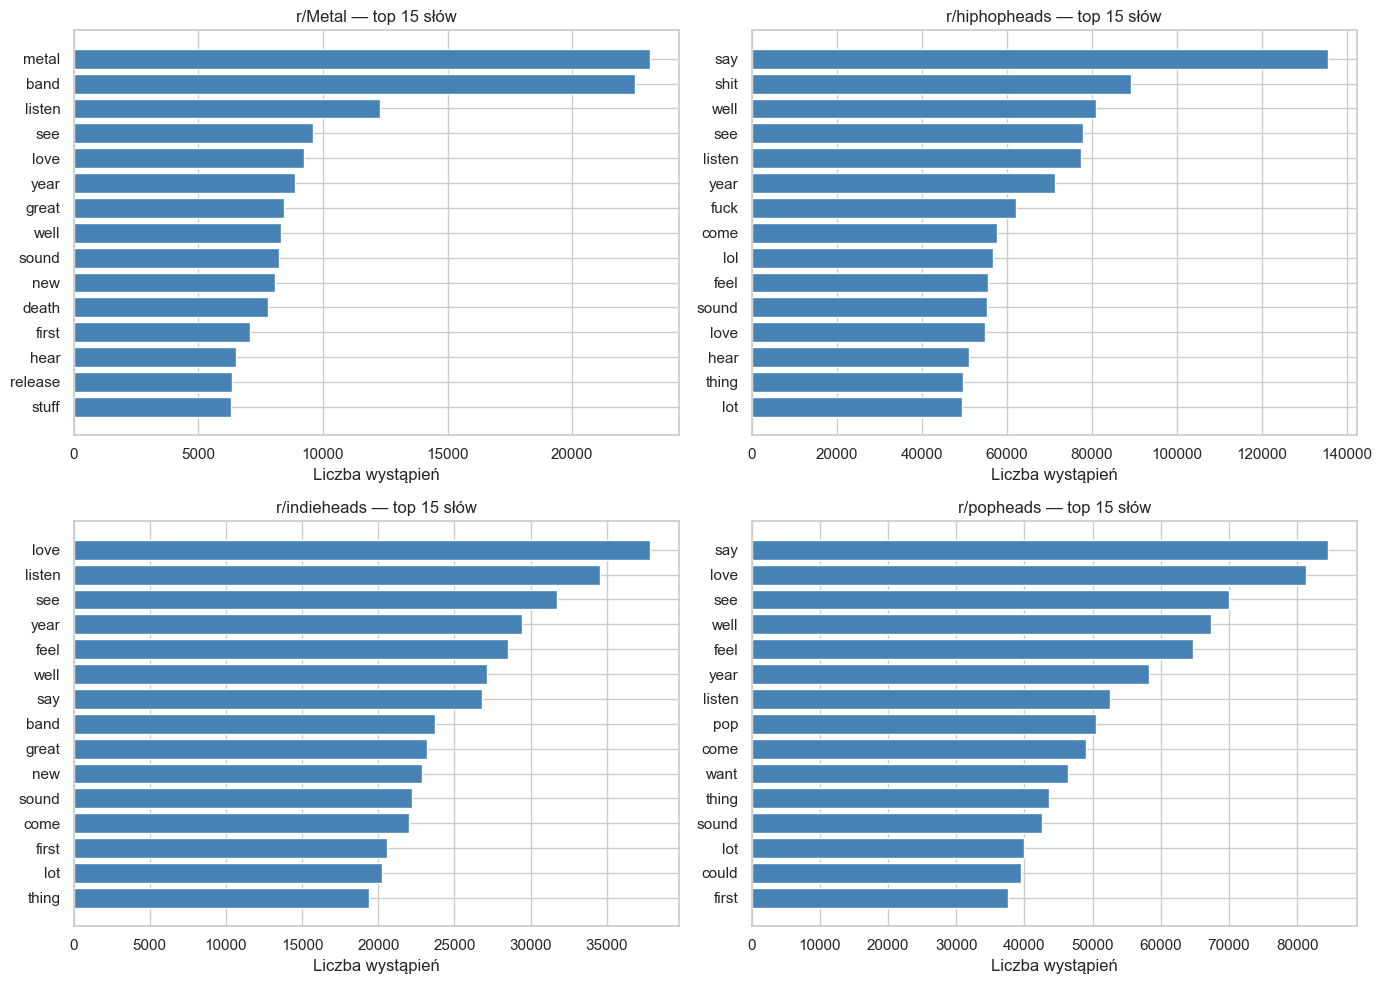

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (sub, group) in enumerate(df.groupby("subreddit")):
    all_tokens = [token for tokens in group["tokens"] for token in tokens]
    top_words = Counter(all_tokens).most_common(15)

    words, counts = zip(*top_words)
    axes[i].barh(list(words)[::-1], list(counts)[::-1], color="steelblue")
    axes[i].set_title(f"r/{sub} — top 15 słów")
    axes[i].set_xlabel("Liczba wystąpień")

plt.tight_layout()
plt.savefig("../outputs/figures/top_words.png", dpi=150)
plt.show()

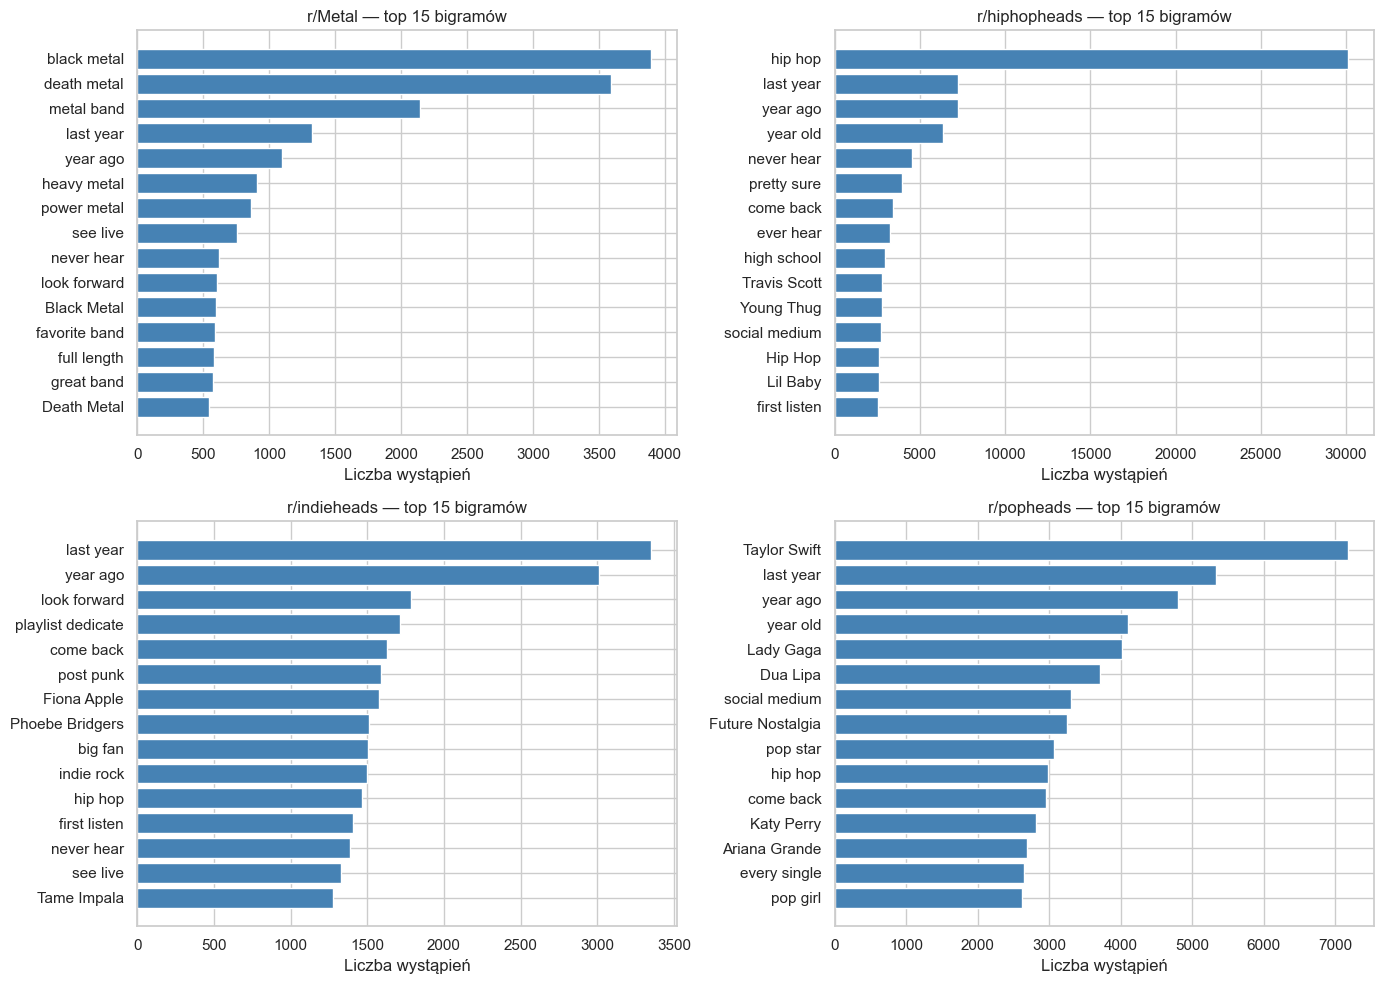

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (sub, group) in enumerate(df.groupby("subreddit")):
    all_tokens = [token for tokens in group["tokens"] for token in tokens]
    bigrams = list(ngrams(all_tokens, 2))
    top_bigrams = Counter(bigrams).most_common(15)

    labels = [f"{a} {b}" for (a, b), _ in top_bigrams]
    counts = [c for _, c in top_bigrams]

    axes[i].barh(labels[::-1], counts[::-1], color="steelblue")
    axes[i].set_title(f"r/{sub} — top 15 bigramów")
    axes[i].set_xlabel("Liczba wystąpień")

plt.tight_layout()
plt.savefig("../outputs/figures/top_bigrams.png", dpi=150)
plt.show()

## 3. Word Clouds

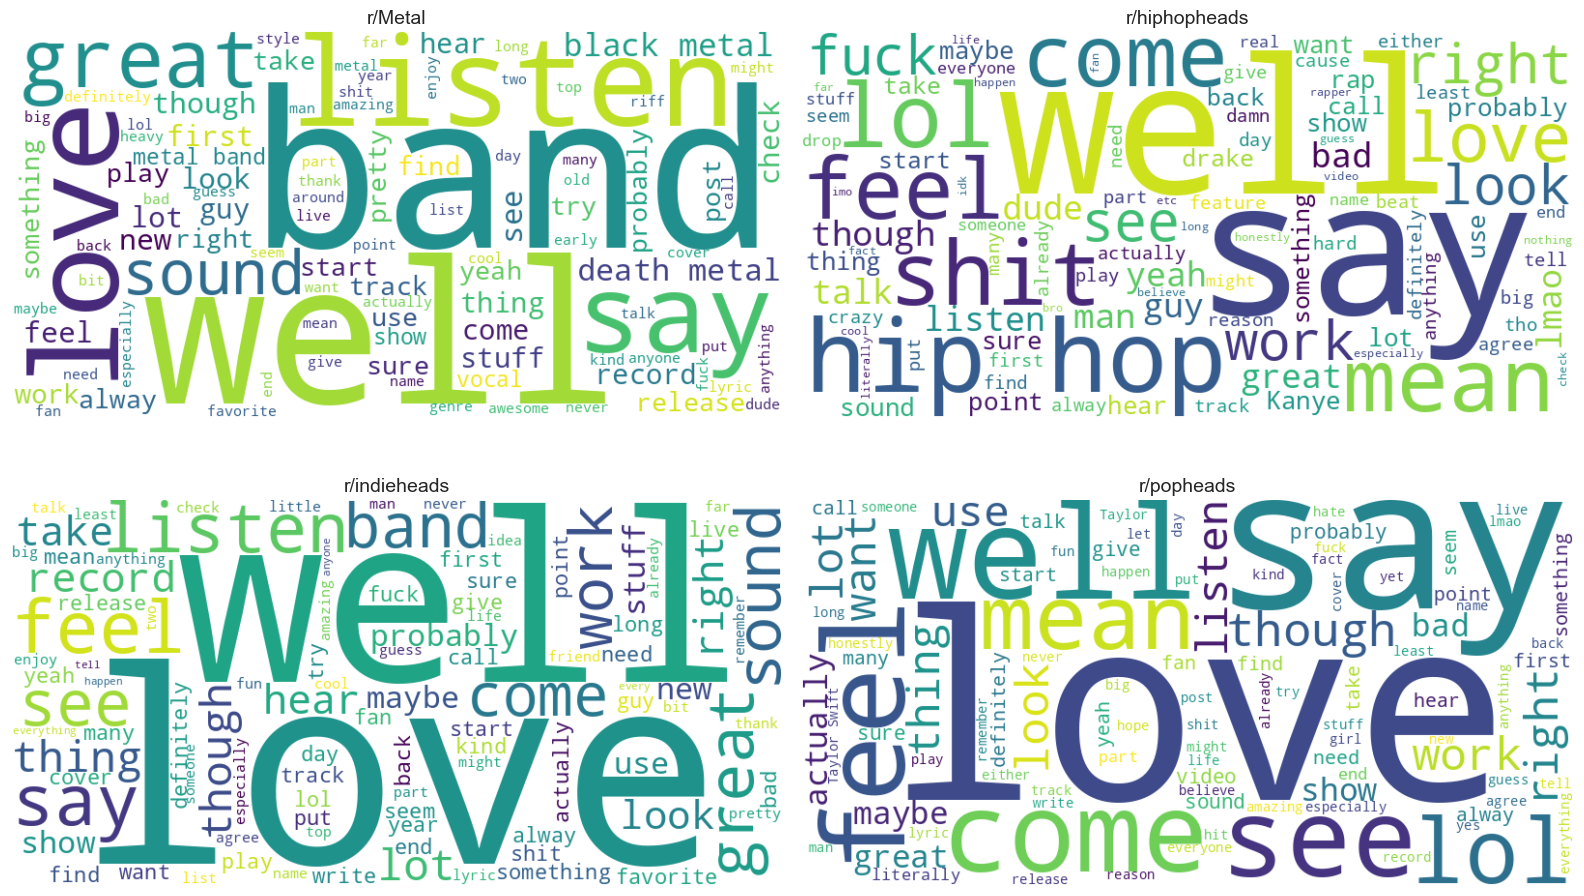

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (sub, group) in enumerate(df.groupby("subreddit")):
    all_tokens = [token for tokens in group["tokens"] for token in tokens]
    text = " ".join(all_tokens)

    wc = WordCloud(width=800, height=400, background_color="white", max_words=100)
    wc.generate(text)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(f"r/{sub}", fontsize=14)

plt.tight_layout()
plt.savefig("../outputs/figures/wordclouds.png", dpi=150)
plt.show()

## 4. Modelowanie tematów (LDA)

In [30]:
NUM_TOPICS = 7
NUM_WORDS  = 10

lda_results = {}

for sub, group in df.groupby("subreddit"):
    print(f"\nr/{sub} — przygotowanie korpusu...")
    
    tokens_list = group["tokens"].tolist()
    tokens_list = [t for t in tokens_list if len(t) > 0]

    dictionary = corpora.Dictionary(tokens_list)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    corpus = [dictionary.doc2bow(tokens) for tokens in tokens_list]

    print(f"  {len(tokens_list)} dokumentów, {len(dictionary)} unikalnych słów")

    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=NUM_TOPICS,
        random_state=42,
        passes=10,
        chunksize=2000,      # przetwarza 2000 dokumentów naraz zamiast domyślnych 2000
        alpha="auto",        # automatycznie dobiera parametr alpha
        eta="auto",          # automatycznie dobiera parametr eta
        per_word_topics=False,
        callbacks=None,
    )

    lda_results[sub] = {"model": lda, "corpus": corpus, "dictionary": dictionary}

    print(f"  Gotowe!")
    print(f"\nr/{sub}:")
    for topic_id, words in lda.print_topics(num_topics=NUM_TOPICS, num_words=NUM_WORDS):
        print(f"  Temat {topic_id + 1}: {words}")


r/Metal — przygotowanie korpusu...
  105345 dokumentów, 17447 unikalnych słów
  Trenuję LDA (7 tematów, 10 przejść)...
  Gotowe!

r/Metal:
  Temat 1: 0.034*"listen" + 0.021*"new" + 0.021*"well" + 0.018*"release" + 0.017*"stuff" + 0.017*"first" + 0.016*"lot" + 0.014*"look" + 0.013*"track" + 0.012*"find"
  Temat 2: 0.062*"Metal" + 0.048*"post" + 0.041*"list" + 0.023*"comment" + 0.018*"sub" + 0.016*"title" + 0.015*"link" + 0.012*"thread" + 0.012*"rec" + 0.009*"please"
  Temat 3: 0.070*"thank" + 0.062*"check" + 0.013*"Dark" + 0.012*"Angel" + 0.008*"Morbid" + 0.008*"Havukruunu" + 0.007*"Fire" + 0.007*"New" + 0.007*"Power" + 0.006*"World"
  Temat 4: 0.018*"see" + 0.017*"love" + 0.017*"year" + 0.016*"great" + 0.012*"hear" + 0.010*"say" + 0.010*"come" + 0.009*"last" + 0.008*"back" + 0.008*"guy"
  Temat 5: 0.010*"voice" + 0.010*"atmospheric" + 0.009*"sing" + 0.008*"grind" + 0.008*"synth" + 0.008*"Ulcerate" + 0.007*"funny" + 0.007*"Witch" + 0.007*"Album" + 0.006*"groove"
  Temat 6: 0.041*"Black

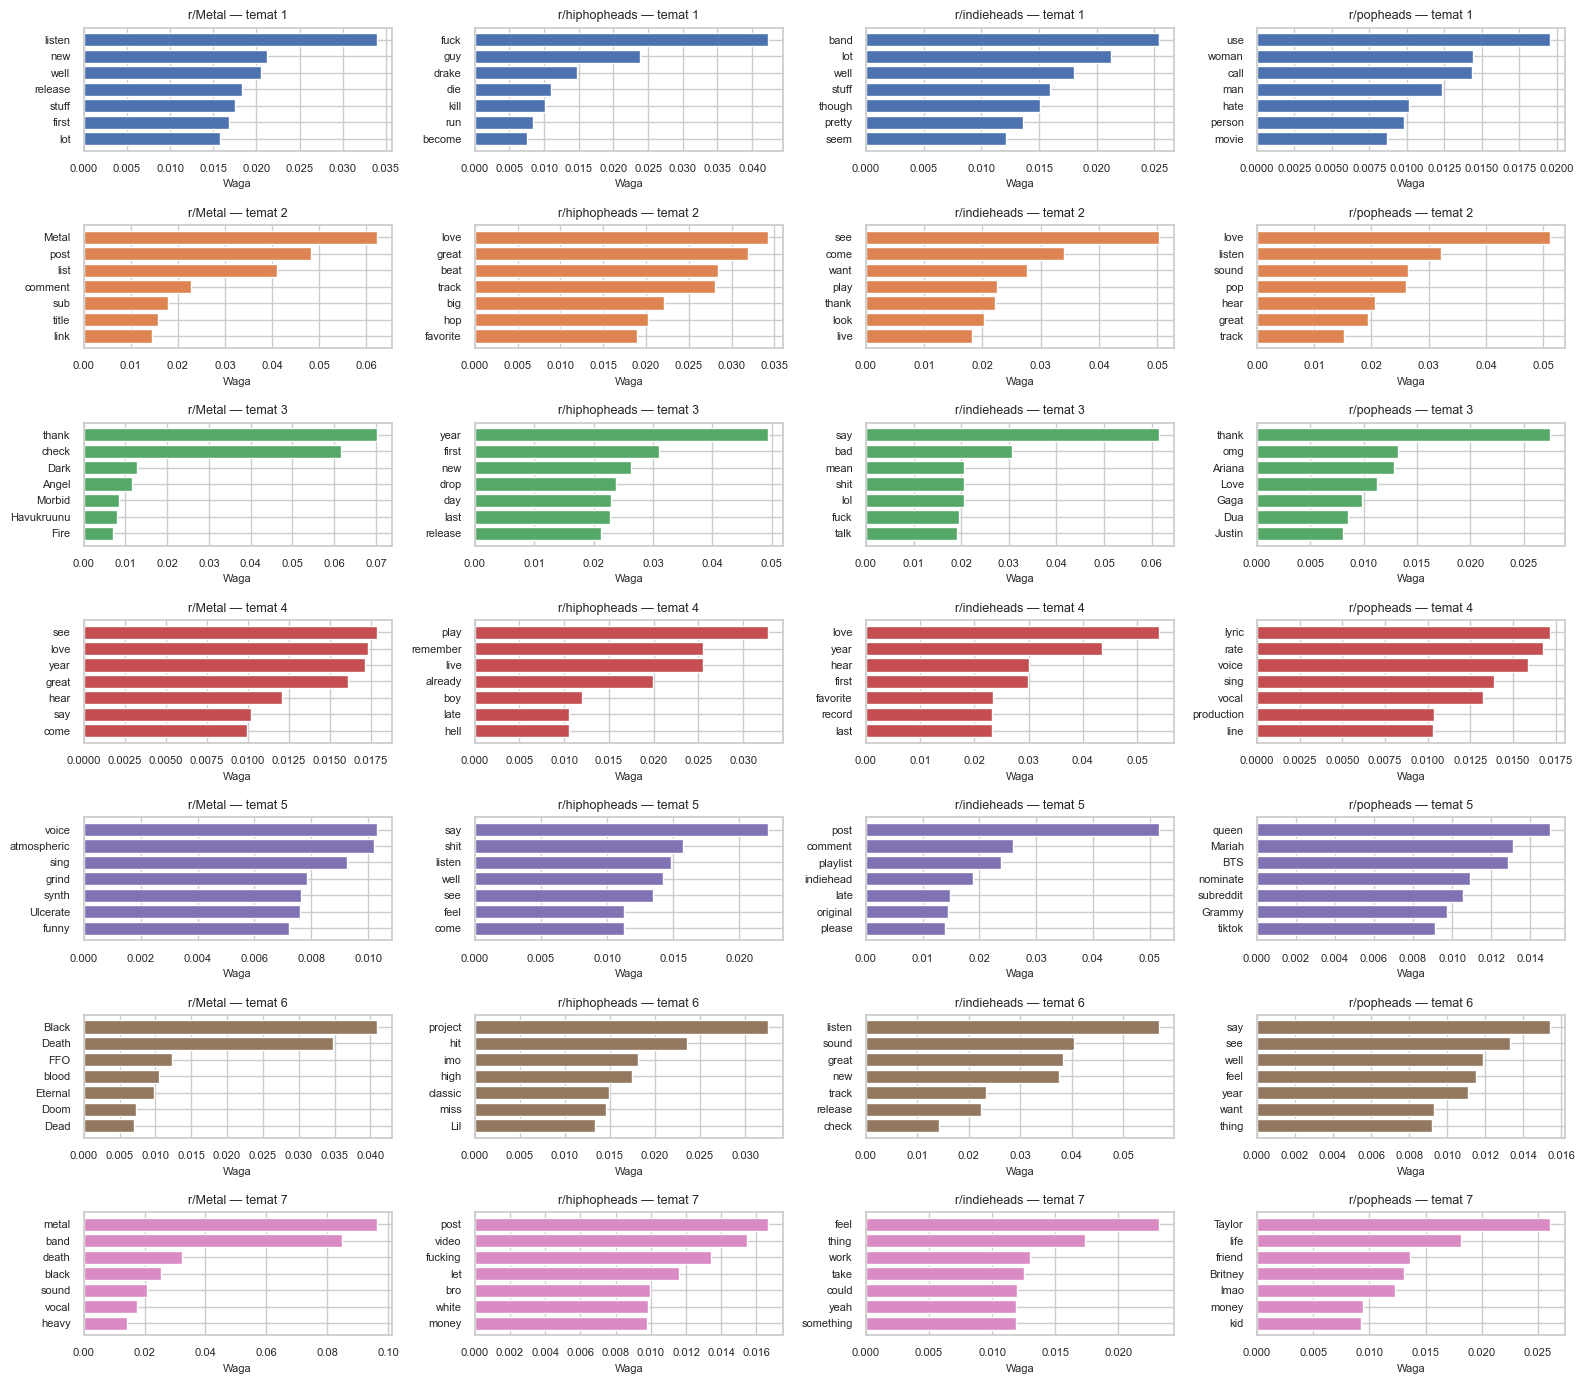

In [31]:
# wizualizacja wag słów dla każdego tematu
fig, axes = plt.subplots(NUM_TOPICS, len(lda_results), figsize=(16, 14))

for col, (sub, result) in enumerate(lda_results.items()):
    lda = result["model"]
    for topic_id in range(NUM_TOPICS):
        ax = axes[topic_id][col]
        top = lda.show_topic(topic_id, topn=7)
        words   = [w for w, _ in top][::-1]
        weights = [p for _, p in top][::-1]
        ax.barh(words, weights, color=f"C{topic_id}")
        ax.set_title(f"r/{sub} — temat {topic_id + 1}", fontsize=9)
        ax.set_xlabel("Waga", fontsize=8)
        ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("../outputs/figures/lda_topics.png", dpi=150)
plt.show()

## 5. Analiza sentymentu (VADER)

In [32]:
analyzer = SentimentIntensityAnalyzer()

# VADER działa na surowym tekście, nie na tokenach
df["sentiment"] = df["body"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"] if isinstance(x, str) else 0
)

# compound to wynik od -1 (bardzo negatywny) do +1 (bardzo pozytywny)
sentiment_stats = df.groupby("subreddit")["sentiment"].agg(["mean", "median"]).round(3)
print(sentiment_stats)

              mean  median
subreddit                 
Metal        0.238   0.338
hiphopheads  0.118   0.000
indieheads   0.287   0.361
popheads     0.247   0.311


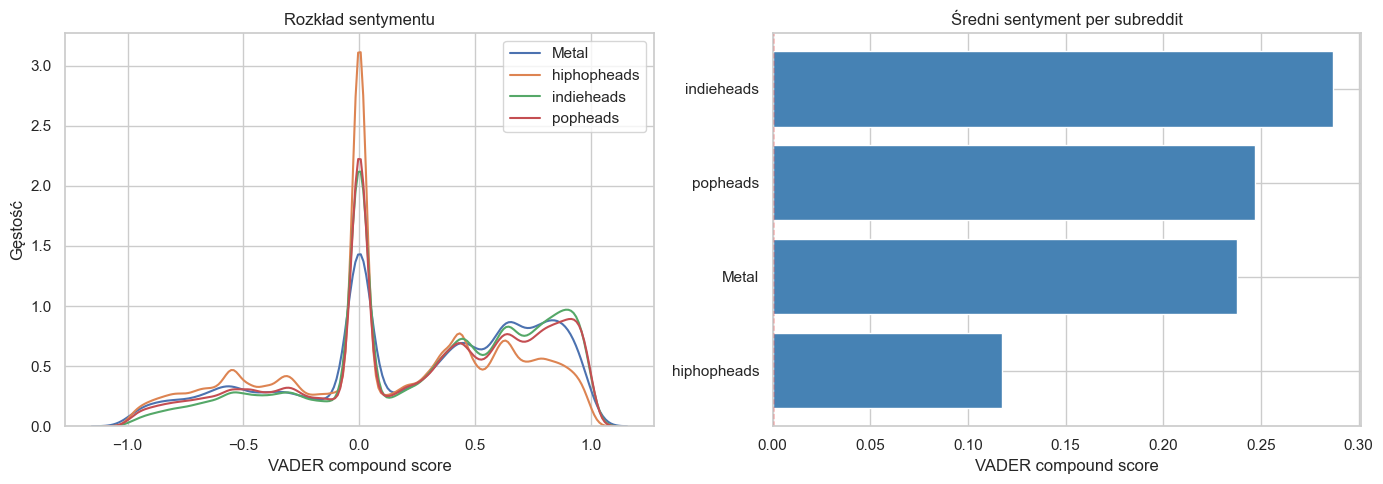

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# rozkład sentymentu per subreddit
for sub, group in df.groupby("subreddit"):
    sns.kdeplot(group["sentiment"], label=sub, ax=axes[0])

axes[0].set_title("Rozkład sentymentu")
axes[0].set_xlabel("VADER compound score")
axes[0].set_ylabel("Gęstość")
axes[0].legend()

# średni sentyment per subreddit
means = df.groupby("subreddit")["sentiment"].mean().sort_values()
axes[1].barh(means.index, means.values, color="steelblue")
axes[1].axvline(x=0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Średni sentyment per subreddit")
axes[1].set_xlabel("VADER compound score")

plt.tight_layout()
plt.savefig("../outputs/figures/sentiment.png", dpi=150)
plt.show()

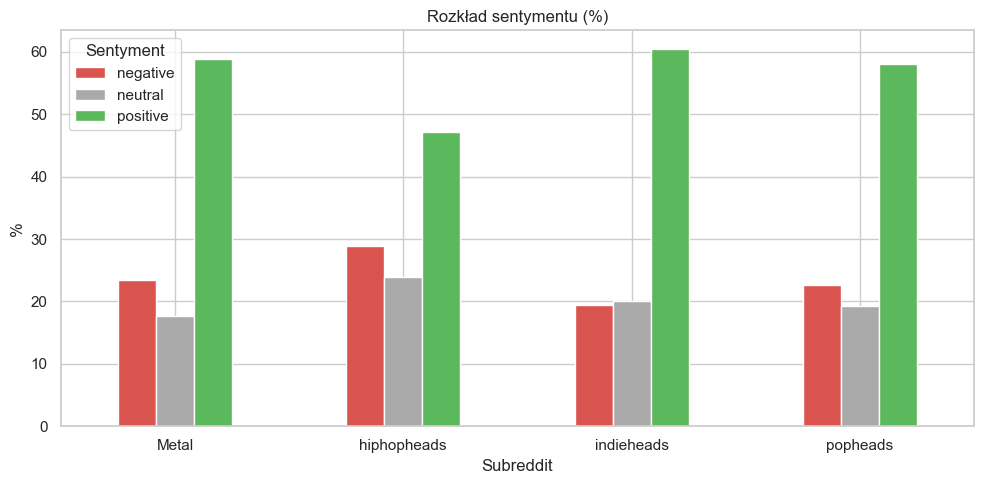

sentiment_label  negative  neutral  positive
subreddit                                   
Metal                23.5     17.6      58.8
hiphopheads          28.9     23.9      47.2
indieheads           19.4     20.1      60.4
popheads             22.7     19.3      58.0


In [34]:
# udział komentarzy pozytywnych, neutralnych i negatywnych
def classify_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment_label"] = df["sentiment"].apply(classify_sentiment)

sentiment_dist = (
    df.groupby(["subreddit", "sentiment_label"])
    .size()
    .unstack()
    .div(df.groupby("subreddit").size(), axis=0)
    .mul(100)
    .round(1)
)

sentiment_dist.plot(kind="bar", figsize=(10, 5), color=["#d9534f", "#aaaaaa", "#5cb85c"])
plt.title("Rozkład sentymentu (%)")
plt.xlabel("Subreddit")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.legend(title="Sentyment")
plt.tight_layout()
plt.savefig("../outputs/figures/sentiment_dist.png", dpi=150)
plt.show()

print(sentiment_dist)

## Wnioski

- ...
- ...
- ...